## Basic Rotterdam-Antwerp trip  
This notebook shows the simple route without locks. There are two routes: Nieuwe Maas and Oude Maas. Some edges had to be removed or forces for these routes. The speed is fixed at 4m/s.

## 0. Import libraries

In [1]:
# packages used for creating and geo-locating the graph
import networkx as nx
import shapely

# packages related to the simulation (creating the vessel, running the simulation)
import datetime
import pickle
import simpy
import opentnsim
import opentnsim.fis as fis
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.plotutils import generate_vessel_gantt_chart
from opentnsim.lock.logutils import add_lock_chamber_dimensions_in_energy_eventtable
from opentnsim.graph.visualizations import plot_graph_folium
from opentnsim.graph.calculations import calculate_length_of_edge

# packages related to the locking module
from opentnsim.lock import lock as lock_module
from opentnsim.vessel_traffic_service import vessel_traffic_service as vessel_traffic_service_module

# packages related to the energy module 
from opentnsim.energy.logutils import (
    add_energy_attributes_to_eventtable,
    add_fuel_attributes_to_event_table,
    add_H2_attributes_to_event_table)

# packages needed for inspecting the output
import pandas as pd
import geopandas as gpd

# packages needed for plotting
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

# plot libraries
import folium

import numpy as np

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.2.2.dev109+g3ac0a4244.d20260416


In [2]:
%load_ext autoreload
%autoreload 2

## 0. Load useful methods 

### A) Network functions

In [3]:
# Method to remove edges  
def safe_remove_edge(G, u, v):
    if G.has_edge(u, v):
        G.remove_edge(u, v)
        G.remove_edge(v,u)
        print(f"Removed edge: {u} -> {v} (both directions)")
    else:
        print(f"Edge {u} -> {v} does not exist (already removed).")

In [4]:
# Method to find the closest node
def find_closest_node(G,point):
    distances, idx = nodes_gdf.sindex.nearest(point)
    # return nodes_gdf.iloc[idx[0]].name
    return nodes_gdf.iloc[idx[0]]

### 1. Define object classes

In [5]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        opentnsim.energy.mixins.ConsumesEnergy,
        lock_module.PassesLockComplex,             # allows to interact with a lock
        opentnsim.core.Identifiable,               # allows to give the object a name and a random ID,
        opentnsim.core.Movable,                    # allows the object to move, with a fixed speed, while logging this activity
        opentnsim.core.VesselProperties,           # allows vessel to have dimensions, namely a length (L), width (B), and draught (T)
        opentnsim.core.ExtraMetadata,              # allow additional information, such as an arrival time (required for passing a lock)
        opentnsim.mixins.HasMultiDiGraph,           # allow to operate on a graph that can include parallel edges from and to the same nodes
        opentnsim.output.HasOutput,                # allow additional output to be stored
    ), 
    {}
)

In [6]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel. 
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

### 2. Create graph
Next we create a network (a graph) along which the vessel can move. For this case we use the Fairway Information System graph, and make the vessel sail from a container terminal at the Maasvlakte to the Kreekrak locks

#### 2.1 Load FIS graph

In [7]:
# with open('FG_correct_distances_with_Volkerak_and_Kreekrak.pickle', 'rb') as handle:
with open('FG_correct_distances_with_Volkerak_and_Kreekrak_Krammer_Hansweert.pickle', 'rb') as handle:
# with open('FG_correct_distances_with_Volkerak_and_Kreekrak_Krammer_Hansweert.pickle', 'rb') as handle:
    FG = pickle.load(handle)

FG = FG.to_directed()

In [50]:
#plot_graph_folium(FG, 4, 50)

#### 2.2 Remove edges 
Edges need to be removed to ensure that the vessels sail representative routes.

### 2.2 Create water depth info on edges + visualize on network 

In this section, we are going to assign a water depth to each individual edge in the graph. At first, the water level (w.r.t. NAP) will be determined for each edge, based on data of waterinfo.nl (RWS). This data is based on a number of measuring points along the Rotterdam-Antwerp corridor.

In [9]:
# Remove Spui (very shallow waterway so most vessels are not able to pass this) 
safe_remove_edge(FG, 'S22992990_A', 'S22992990_B')

# Remove recreational bergediepsluis (not for IWT vessels) 
safe_remove_edge(FG, 'L51819_A', 'L51819_B')

# Remove recreational lock volkerak (not for IWT vessels) 
safe_remove_edge(FG, 'B46500_A', 'B46500_B')

# Remove Rietbaan in nieuwe Maas route (this edge creates a loop)
# TO DO: find out why this removes Noord instead of Rietbaan?? --> difference not so relevant though
safe_remove_edge(FG, '8863048', '8866570') 

Removed edge: S22992990_A -> S22992990_B (both directions)
Removed edge: L51819_A -> L51819_B (both directions)
Removed edge: B46500_A -> B46500_B (both directions)
Removed edge: 8863048 -> 8866570 (both directions)


#### 2.3 Plan route 

In [10]:
maasvlakte     = shapely.Point(4.056694, 51.947162)
volkerak       = shapely.Point(4.409331, 51.690440)
kreekrak       = shapely.Point(4.228202, 51.461103)
meerhout       = shapely.Point(5.096662, 51.098779)
antwerp        = shapely.Point(4.344243, 51.279407)
botlek         = shapely.Point(4.315013, 51.894716)
erasmus_bridge = shapely.Point(4.486020, 51.908346)
krammer        = shapely.Point(4.160114, 51.661751)
hansweert      = shapely.Point(4.010556, 51.455824)
Noord1         = shapely.Point(4.622453,51.8854942)
Noord2         = shapely.Point(4.669784,51.8240557)
Scheldt_Rhine1 = shapely.Point(4.194823,51.6149341) 
Scheldt_Rhine2 = shapely.Point(4.220736,51.4943026)
antwerp_ZB     = shapely.Point(4.262775,51.3438188)
antwerp_SR     = shapely.Point(4.296340,51.3441803)

In [11]:
nodes_gdf = gpd.GeoDataFrame(FG.nodes.values(), index=FG.nodes.keys())

In [12]:
# Find closest nodes for the locations
# Start locations
maasvlakte_node  = find_closest_node(FG,maasvlakte)
botlek_node      = find_closest_node(FG,botlek)
# Locks
volkerak_node   = find_closest_node(FG,volkerak)
kreekrak_node    = find_closest_node(FG,kreekrak)
krammer_node     = find_closest_node(FG,krammer)
hansweert_node   = find_closest_node(FG,hansweert)
# End locations
antwerp_node     = find_closest_node(FG,antwerp)
meerhout_node    = find_closest_node(FG,meerhout)
# Nieuwe maas route needs to pass the Erasmus bridge
erasmus_bridge_node      = find_closest_node(FG,erasmus_bridge)
# Shallow water start and end points
Noord1_node = find_closest_node(FG,Noord1)
Noord2_node = find_closest_node(FG,Noord2)
Scheldt_Rhine1_node = find_closest_node(FG,Scheldt_Rhine1)
Scheldt_Rhine2_node = find_closest_node(FG,Scheldt_Rhine2)
# End points
antwerp_ZB_node = find_closest_node(FG,antwerp_ZB)
antwerp_SR_node = find_closest_node(FG,antwerp_SR)

In [13]:
# Use network x to create the different routes
route_OM_SR = nx.shortest_path(FG, botlek_node.name, antwerp_SR_node.name, weight='length_m')

route_NM_SR = (
    nx.shortest_path(FG, botlek_node.name, erasmus_bridge_node.name, weight='length_m')
    + nx.shortest_path(FG, erasmus_bridge_node.name, antwerp_SR_node.name, weight='length_m')[1:])

route_OM_ZB = (
    nx.shortest_path(FG, botlek_node.name, hansweert_node.name, weight='length_m')
    + nx.shortest_path(FG, hansweert_node.name, antwerp_ZB_node.name, weight='length_m')[1:])

route_NM_ZB = (
    nx.shortest_path(FG, botlek_node.name, erasmus_bridge_node.name, weight='length_m')
    +nx.shortest_path(FG, erasmus_bridge_node.name, hansweert_node.name, weight='length_m')[1:]
    + nx.shortest_path(FG, hansweert_node.name, antwerp_ZB_node.name, weight='length_m')[1:])

shallow_NM = nx.shortest_path(FG, Noord1_node.name, Noord2_node.name, weight='length_m')
shallow_SR = nx.shortest_path(FG, Scheldt_Rhine1_node.name, Scheldt_Rhine2_node.name, weight='length_m')

In [14]:
shallow_NM_set = set(shallow_NM)
shallow_SR_set = set(shallow_SR)

for u, v in FG.edges():
    FG.edges[u, v]["GeneralDepth"] = 6
    # Reduce water depth for shallow parts of the route
    if u in shallow_NM_set or v in shallow_NM_set:
        FG.edges[u, v]["GeneralDepth"] = 4.4
    if u in shallow_SR_set or v in shallow_SR_set:
        FG.edges[u, v]["GeneralDepth"] = 4.3

### 3. Run simulation
##### 3.1 Set mission and simpy environment with VTS

In [15]:
# start simpy environment
simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start
env.graph = FG

# add components important for locking to the environment
env.vessel_traffic_service = vessel_traffic_service_module.VesselTrafficService(graph=FG, crs_m = "EPSG:28992") #Amersfoort / RD New reference system

In [16]:
data_vessel_1 = {
    "env": env,
    "name": 'M8 loaded passing OM+SR',           # you can give the vessel an arbitratry name
    "type": 'P_tot_given=P_installed', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 3.5,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    # "v": None,                     # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,            # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    # "P_tot_given": 1750.0*0.35,        #
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": True, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 1, 0, 0, 0),
    "geometry": env.graph.nodes[route_OM_SR[0]]['geometry'],
    "route": route_OM_SR,             # the route to sail
}  # 

data_vessel_2 = {
    "env": env,
    "name": 'M8 loaded passing NM+SR',           # you can give the vessel an arbitratry name
    "type": 'P_tot_given=P_installed', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 3.5,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    # "v": None,                     # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,            # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    # "P_tot_given": 1750.0*0.35,        #
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": True, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 2, 0, 0, 0),
    "geometry": env.graph.nodes[route_NM_SR[0]]['geometry'],
    "route": route_NM_SR,             # the route to sail
}  # 

data_vessel_3 = {
    "env": env,
    "name": 'M8 loaded passing OM+ZB',           # you can give the vessel an arbitratry name
    "type": 'P_tot_given=P_installed', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 3.5,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    # "v": None,                     # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,            # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    # "P_tot_given": 1750.0*0.35,        #
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": True, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 3, 0, 0, 0),
    "geometry": env.graph.nodes[route_OM_ZB[0]]['geometry'],
    "route": route_OM_ZB,             # the route to sail
}  # 

data_vessel_4 = {
    "env": env,
    "name": 'M8 loaded passing NM+ZB',           # you can give the vessel an arbitratry name
    "type": 'P_tot_given=P_installed', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 3.5,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    # "v": None,                     # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,            # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    # "P_tot_given": 1750.0*0.35,        #
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": True, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 4, 0, 0, 0),
    "geometry": env.graph.nodes[route_NM_ZB[0]]['geometry'],
    "route": route_NM_ZB,             # the route to sail
}  # 

# create an instance of the Vessel class using the input dict data_vessel
vessel_1 = Vessel(**data_vessel_1)
vessel_2 = Vessel(**data_vessel_2)
vessel_3 = Vessel(**data_vessel_3)
vessel_4 = Vessel(**data_vessel_4)

# env.process(mission(env, vessel_1))
# env.process(mission(env, vessel_2))
# env.process(mission(env, vessel_3))
# env.process(mission(env, vessel_4))


##### 3.2 Create lock objects

In [17]:
with open('Volkerak_information.pickle', 'rb') as handle:
    information_Volkerak = pickle.load(handle)

In [18]:
Volkerak = lock_module.IsLockComplex(
    env = env,
    name = 'Volkerak',
    node_open = information_Volkerak["lock_node_A"],
    node_A = information_Volkerak["lock_node_A"],
    node_B = information_Volkerak["lock_node_B"],
    edge_waiting_area_A = information_Volkerak["edge_waiting_area_A"], 
    edge_waiting_area_B = information_Volkerak["edge_waiting_area_B"],
    distance_lock_doors_A_to_waiting_area_A = information_Volkerak["distance_lock_doors_A_to_waiting_area_A"],
    distance_lock_doors_B_to_waiting_area_B = information_Volkerak["distance_lock_doors_B_to_waiting_area_B"],
    distance_from_start_node_to_lock_doors_A = information_Volkerak["distance_from_start_node_to_lock_doors_A"],
    distance_from_end_node_to_lock_doors_B = information_Volkerak["distance_from_end_node_to_lock_doors_B"],
    lock_length = information_Volkerak["lock_length"],
    lock_width = information_Volkerak["lock_width"],
    lock_depth = information_Volkerak["lock_depth"],
    levelling_time = 700,
    sailing_distance_to_crossing_point = 300,
    doors_opening_time= 100,
    doors_closing_time= 100,
    speed_reduction_factor_lock_chamber=0.25,
    sailing_in_time_gap_through_doors = 240,
    sailing_in_speed_sea = 1.5,
    sailing_in_speed_canal = 1.5,
    sailing_out_time_gap_through_doors = 60,
    sailing_time_before_opening_lock_doors = 600,
    sailing_time_before_closing_lock_doors = 120,
    mandatory_waiting_time_before_lock = 900,
    registration_nodes = [information_Volkerak["node_A"], information_Volkerak["node_B"]],
)

In [19]:
with open('Kreekrak_information.pickle', 'rb') as handle:
    information_Kreekrak = pickle.load(handle)

In [20]:
Kreekrak = lock_module.IsLockComplex(
    env = env,
    name = 'Kreekrak',
    node_open = information_Kreekrak["lock_node_A"],
    node_A = information_Kreekrak["lock_node_A"],
    node_B = information_Kreekrak["lock_node_B"],
    edge_waiting_area_A = information_Kreekrak["edge_waiting_area_A"], 
    edge_waiting_area_B = information_Kreekrak["edge_waiting_area_B"],
    distance_lock_doors_A_to_waiting_area_A = information_Kreekrak["distance_lock_doors_A_to_waiting_area_A"],
    distance_lock_doors_B_to_waiting_area_B = information_Kreekrak["distance_lock_doors_B_to_waiting_area_B"],
    distance_from_start_node_to_lock_doors_A = information_Kreekrak["distance_from_start_node_to_lock_doors_A"],
    distance_from_end_node_to_lock_doors_B = information_Kreekrak["distance_from_end_node_to_lock_doors_B"],
    lock_length = information_Kreekrak["lock_length"],
    lock_width = information_Kreekrak["lock_width"],
    lock_depth = information_Kreekrak["lock_depth"],
    levelling_time = 500,
    sailing_distance_to_crossing_point = 300,
    doors_opening_time= 100,
    doors_closing_time= 100,
    speed_reduction_factor_lock_chamber=0.25,
    sailing_in_time_gap_through_doors = 240,
    sailing_in_speed_sea = 1.5,
    sailing_in_speed_canal = 1.5,
    sailing_out_time_gap_through_doors = 60,
    sailing_time_before_opening_lock_doors = 600,
    sailing_time_before_closing_lock_doors = 120,
    mandatory_waiting_time_before_lock = 900,
    registration_nodes = [information_Kreekrak["node_A"], information_Kreekrak["node_B"]],
)

In [21]:
with open('Krammer_information.pickle', 'rb') as handle:
    information_Krammer = pickle.load(handle)

In [22]:
Krammer = lock_module.IsLockComplex(
    env = env,
    name = 'Krammer',
    node_open = information_Krammer["lock_node_A"],
    node_A = information_Krammer["lock_node_A"],
    node_B = information_Krammer["lock_node_B"],
    edge_waiting_area_A = information_Krammer["edge_waiting_area_A"], 
    edge_waiting_area_B = information_Krammer["edge_waiting_area_B"],
    distance_lock_doors_A_to_waiting_area_A = information_Krammer["distance_lock_doors_A_to_waiting_area_A"],
    distance_lock_doors_B_to_waiting_area_B = information_Krammer["distance_lock_doors_B_to_waiting_area_B"],
    distance_from_start_node_to_lock_doors_A = information_Krammer["distance_from_start_node_to_lock_doors_A"],
    distance_from_end_node_to_lock_doors_B = information_Krammer["distance_from_end_node_to_lock_doors_B"],
    lock_length = information_Krammer["lock_length"],
    lock_width = information_Krammer["lock_width"],
    lock_depth = information_Krammer["lock_depth"],
    levelling_time = 500,
    sailing_distance_to_crossing_point = 300,
    # sailing_distance_to_crossing_point = 10000,
    doors_opening_time= 100,
    doors_closing_time= 100,
    speed_reduction_factor_lock_chamber=0.25,
    sailing_in_time_gap_through_doors = 240,
    sailing_in_speed_sea = 1.5,
    sailing_in_speed_canal = 1.5,
    sailing_out_time_gap_through_doors = 60,
    sailing_time_before_opening_lock_doors = 600,
    sailing_time_before_closing_lock_doors = 120,
    mandatory_waiting_time_before_lock = 900,
    registration_nodes = [information_Krammer["node_A"], information_Krammer["node_B"]],
)

In [23]:
with open('Hansweert_information.pickle', 'rb') as handle:
    information_Hansweert = pickle.load(handle)

In [24]:
Hansweert = lock_module.IsLockComplex(
    env = env,
    name = 'Hansweert',
    node_open = information_Hansweert["lock_node_A"],
    node_A = information_Hansweert["lock_node_A"],
    node_B = information_Hansweert["lock_node_B"],
    edge_waiting_area_A = information_Hansweert["edge_waiting_area_A"], 
    edge_waiting_area_B = information_Hansweert["edge_waiting_area_B"],
    distance_lock_doors_A_to_waiting_area_A = information_Hansweert["distance_lock_doors_A_to_waiting_area_A"],
    distance_lock_doors_B_to_waiting_area_B = information_Hansweert["distance_lock_doors_B_to_waiting_area_B"],
    distance_from_start_node_to_lock_doors_A = information_Hansweert["distance_from_start_node_to_lock_doors_A"],
    distance_from_end_node_to_lock_doors_B = information_Hansweert["distance_from_end_node_to_lock_doors_B"],
    lock_length = information_Hansweert["lock_length"],
    lock_width = information_Hansweert["lock_width"],
    lock_depth = information_Hansweert["lock_depth"],
    levelling_time = 500,
    sailing_distance_to_crossing_point = 300,
    doors_opening_time= 100,
    doors_closing_time= 100,
    speed_reduction_factor_lock_chamber=0.25,
    sailing_in_time_gap_through_doors = 240,
    sailing_in_speed_sea = 1.5,
    sailing_in_speed_canal = 1.5,
    sailing_out_time_gap_through_doors = 60,
    sailing_time_before_opening_lock_doors = 600,
    sailing_time_before_closing_lock_doors = 120,
    mandatory_waiting_time_before_lock = 900,
    registration_nodes = [information_Hansweert["node_A"], information_Hansweert["node_B"]],
)

In [25]:
# start the simulation
env.process(mission(env, vessel_1))
env.process(mission(env, vessel_2))
env.process(mission(env, vessel_3))
env.process(mission(env, vessel_4))

env.run()

#### Volkerak time-distance plots

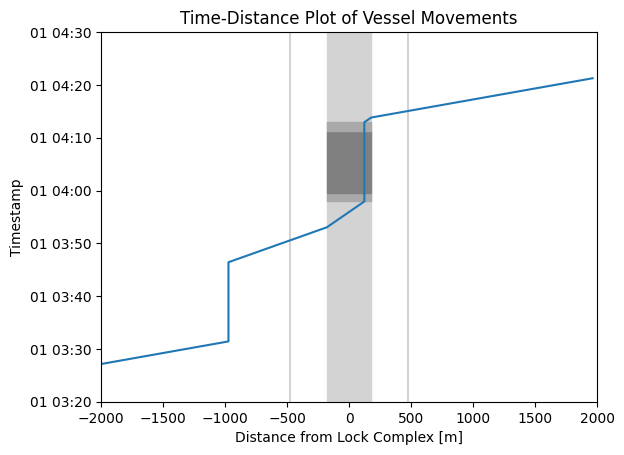

In [105]:
# We can plot the time-distance diagram
fig = Volkerak.create_time_distance_plot(
    vessels = [vessel_1], 
    xlimmin = -2000,
    xlimmax = 2000, 
    ylimmin = pd.Timestamp('2024-01-01 03:20'),
    ylimmax = pd.Timestamp('2024-01-01 04:30'),
    label='modelled')
fig

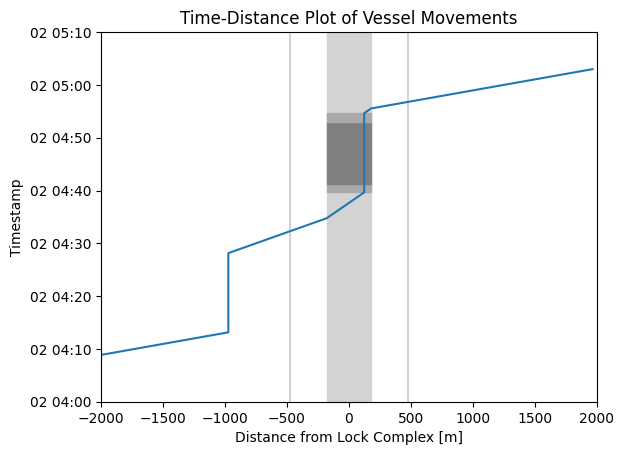

In [106]:
# We can plot the time-distance diagram
fig = Volkerak.create_time_distance_plot(
    vessels = [vessel_2], 
    xlimmin = -2000,
    xlimmax = 2000, 
    ylimmin = pd.Timestamp('2024-01-02 04:00'),
    ylimmax = pd.Timestamp('2024-01-02 05:10'),
    label='modelled')
fig

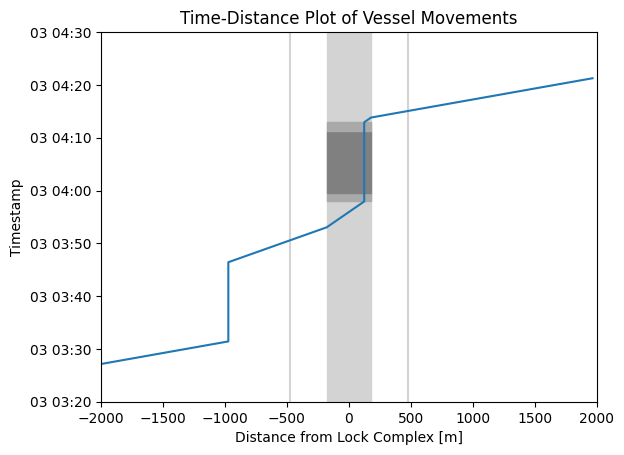

In [107]:
# We can plot the time-distance diagram
fig = Volkerak.create_time_distance_plot(
    vessels = [vessel_3], 
    xlimmin = -2000,
    xlimmax = 2000, 
    ylimmin = pd.Timestamp('2024-01-03 03:20'),
    ylimmax = pd.Timestamp('2024-01-03 04:30'),
    label='modelled')
fig

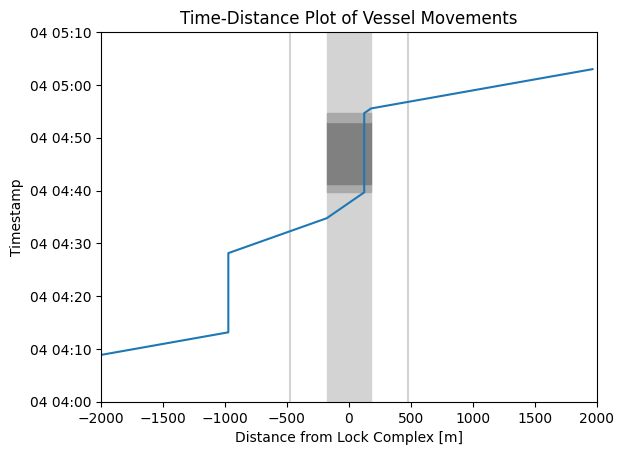

In [108]:
# We can plot the time-distance diagram
fig = Volkerak.create_time_distance_plot(
    vessels = [vessel_4], 
    xlimmin = -2000,
    xlimmax = 2000, 
    ylimmin = pd.Timestamp('2024-01-04 04:00'),
    ylimmax = pd.Timestamp('2024-01-04 05:10'),
    label='modelled')
fig

#### Kreekrak time-distance plots

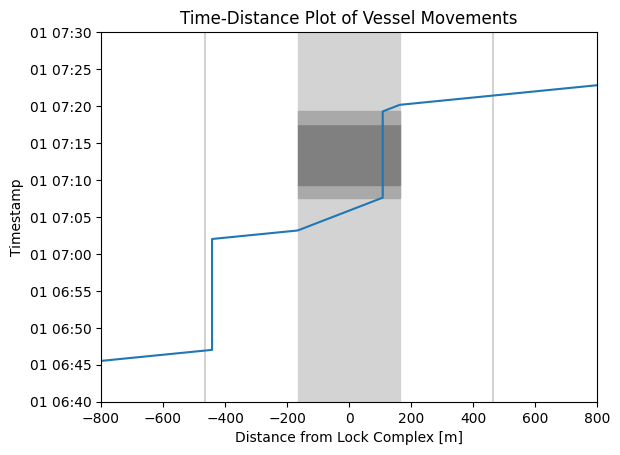

In [109]:
fig = Kreekrak.create_time_distance_plot(
    vessels = [vessel_1], 
    xlimmin = -800, 
    xlimmax = 800, 
    ylimmin = pd.Timestamp('2024-01-01 06:40'),
    ylimmax = pd.Timestamp('2024-01-01 07:30'),
    label='modelled')
fig

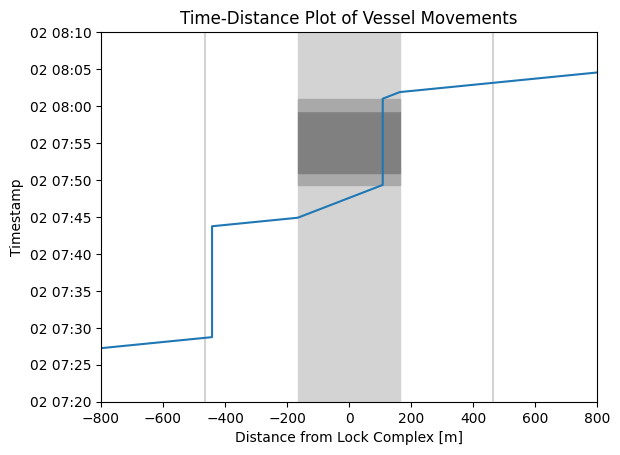

In [110]:
fig = Kreekrak.create_time_distance_plot(
    vessels = [vessel_2], 
    xlimmin = -800, 
    xlimmax = 800, 
    ylimmin = pd.Timestamp('2024-01-02 07:20'),
    ylimmax = pd.Timestamp('2024-01-02 08:10'),
    label='modelled')
fig

#### Krammer time-distance plots

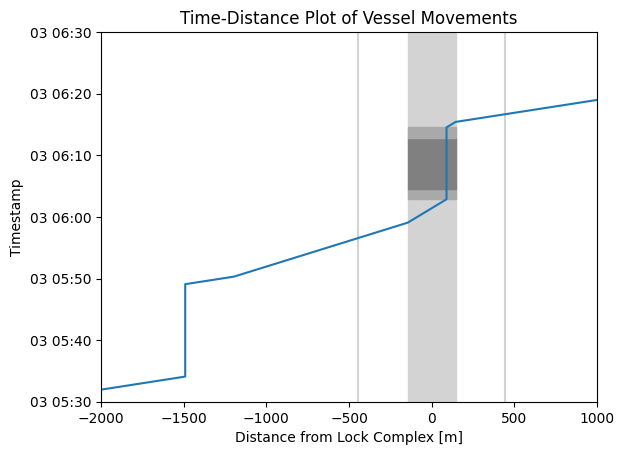

In [111]:
fig = Krammer.create_time_distance_plot(
    vessels = [vessel_3], 
    xlimmin = -2000, 
    xlimmax = 1000, 
    ylimmin = pd.Timestamp('2024-01-03 05:30'),
    ylimmax = pd.Timestamp('2024-01-03 06:30'),
    label='modelled')
fig

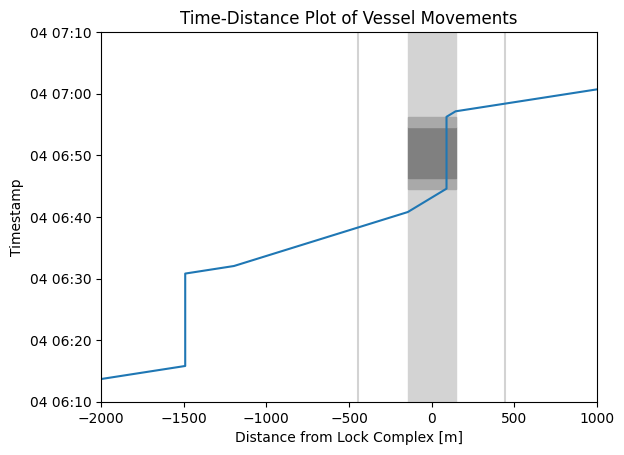

In [112]:
fig = Krammer.create_time_distance_plot(
    vessels = [vessel_4], 
    xlimmin = -2000, 
    xlimmax = 1000, 
    ylimmin = pd.Timestamp('2024-01-04 06:10'),
    ylimmax = pd.Timestamp('2024-01-04 07:10'),
    label='modelled')
fig

#### Hansweert time-distance plots

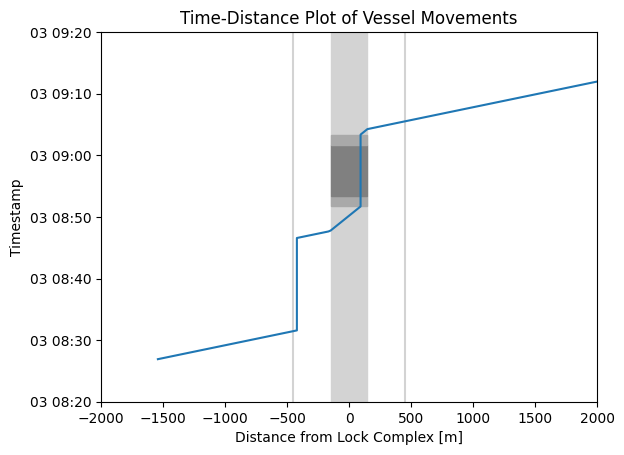

In [116]:
fig = Hansweert.create_time_distance_plot(
    vessels = [vessel_3], 
    xlimmin = -1500, 
    xlimmax = xlimmax,
    ylimmin = pd.Timestamp('2024-01-03 08:20'),
    ylimmax = pd.Timestamp('2024-01-03 09:20'),
    label='modelled')
fig

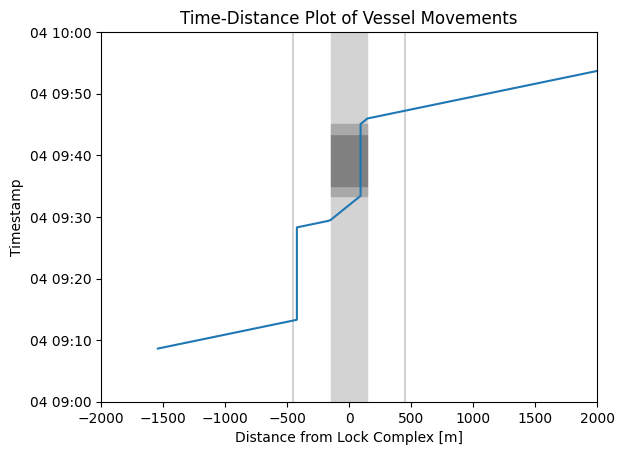

In [115]:
fig = Hansweert.create_time_distance_plot(
    vessels = [vessel_4], 
    xlimmin = xlimmin, 
    xlimmax = xlimmax,
    ylimmin = pd.Timestamp('2024-01-04 09:00'),
    ylimmax = pd.Timestamp('2024-01-04 10:00'),
    label='modelled')
fig

### 4. Inspect output
We can now inspect  the simulation output by inspecting the _vessel.logbook_. Note that the _Log_ mix-in was included when we added _Movable_. The _vessel.logbook_ keeps track of the moving activities of the vessel. For each discrete event OpenTNSim logs an event message, the start/stop time and the location. The _vessel.logbook_ is of type dict. For convenient inspection it can be loaded into a Pandas dataframe. 

In [33]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_1.logbook)

print("'{}' logbook data:".format(vessel_1.name))  
print('')

pd.set_option('display.max_rows', None)
display(df)

'M8 loaded passing OM+SR' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 8861716 to node B17838816_B ...,2024-01-01 00:00:00.000000,0,POINT (4.32003340516321 51.8944476699094)
1,Sailing from node 8861716 to node B17838816_B ...,2024-01-01 00:11:11.550698,2686.202792,POINT (4.331101754547955 51.87131584461907)
2,Sailing from node B17838816_B to node B1783881...,2024-01-01 00:11:11.550698,2686.202792,POINT (4.331101754547955 51.87131584461907)
3,Sailing from node B17838816_B to node B1783881...,2024-01-01 00:11:14.127663,2696.510652,POINT (4.331149675825261 51.871228074742795)
4,Sailing from node B17838816_A to node 8865803 ...,2024-01-01 00:11:14.127663,2696.510652,POINT (4.331149675825261 51.871228074742795)
5,Sailing from node B17838816_A to node 8865803 ...,2024-01-01 00:13:20.678346,3202.713384,POINT (4.33350300310146 51.866917854826305)
6,Sailing from node 8865803 to node 8862143 start,2024-01-01 00:13:20.678346,3202.713384,POINT (4.33350300310146 51.866917854826305)
7,Sailing from node 8865803 to node 8862143 stop,2024-01-01 00:14:41.633785,3526.535139,POINT (4.33506263254959 51.864172165469505)
8,Sailing from node 8862143 to node B42792_B start,2024-01-01 00:14:41.633785,3526.535139,POINT (4.33506263254959 51.864172165469505)
9,Sailing from node 8862143 to node B42792_B stop,2024-01-01 00:17:15.111488,4140.445951,POINT (4.340053200020321 51.859600597806946)


The inspection of the logbook data shows that Vessel moved from its origin (*Node 0*) to its destination (*Node 1*). The print statements show that the length of the route from *Node 0* to *Node 1* is exactly 100 km. At a given speed of 1 m/s the trip duration should be exactly 100000 seconds, as is indeed shown to be the case.

In [34]:
# df_eventtable = logbook2eventtable([vessel_1])
df_eventtable = logbook2eventtable([vessel_1, vessel_2, vessel_3, vessel_4])
df_eventtable

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s)
0,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node 8861716 to node B17838816_B,,POINT (4.32003340516321 51.8944476699094),POINT (4.331101754547955 51.87131584461907),2024-01-01 00:00:00,2024-01-01 00:11:12,2686.202792,671.550698
1,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node B17838816_B to node B17838816_A,,POINT (4.331101754547955 51.87131584461907),POINT (4.331149675825261 51.871228074742795),2024-01-01 00:11:12,2024-01-01 00:11:14,10.307860,2.576965
2,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node B17838816_A to node 8865803,,POINT (4.331149675825261 51.871228074742795),POINT (4.33350300310146 51.866917854826305),2024-01-01 00:11:14,2024-01-01 00:13:21,506.202732,126.550683
3,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node 8865803 to node 8862143,,POINT (4.33350300310146 51.866917854826305),POINT (4.33506263254959 51.864172165469505),2024-01-01 00:13:21,2024-01-01 00:14:42,323.821755,80.955439
4,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node 8862143 to node B42792_B,,POINT (4.33506263254959 51.864172165469505),POINT (4.340053200020321 51.859600597806946),2024-01-01 00:14:42,2024-01-01 00:17:15,613.910812,153.477703
5,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node B42792_B to node B42792_A,,POINT (4.340053200020321 51.859600597806946),POINT (4.340125260900426 51.859531369318596),2024-01-01 00:17:15,2024-01-01 00:17:17,9.168936,2.292234
6,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node B42792_A to node 8867784,,POINT (4.340125260900426 51.859531369318596),POINT (4.34220631701808 51.8572692964818),2024-01-01 00:17:17,2024-01-01 00:18:30,289.645631,72.411408
7,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node 8867784 to node 8864737,,POINT (4.34220631701808 51.8572692964818),POINT (4.43200716599724 51.8367377400882),2024-01-01 00:18:30,2024-01-01 00:47:36,6984.781815,1746.195453
8,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node 8864737 to node 8867023,,POINT (4.43200716599724 51.8367377400882),POINT (4.52760808152354 51.8302649043596),2024-01-01 00:47:36,2024-01-01 01:16:12,6865.180650,1716.295163
9,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node 8867023 to node 8863810,,POINT (4.52760808152354 51.8302649043596),POINT (4.56623163072507 51.812486619297296),2024-01-01 01:16:12,2024-01-01 01:33:06,4054.016523,1013.504130


In [35]:
# add energy attributes to the minimum event table
df_eventtable_energy = add_energy_attributes_to_eventtable(df_eventtable, [vessel_1, vessel_2, vessel_3, vessel_4])        
df_eventtable_energy = add_lock_chamber_dimensions_in_energy_eventtable(df_eventtable_energy, env)
# pd.set_option('display.max_columns', None)
df_eventtable_energy

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),velocity (m/s),waterdepth (m),waterway width (m),current (m/s),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh)
0,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node 8861716 to node B17838816_B,,POINT (4.32003340516321 51.8944476699094),POINT (4.331101754547955 51.87131584461907),2024-01-01 00:00:00,2024-01-01 00:11:12,2686.202792,671.550698,4.000000,6.0,None,0.0,619.443950,619.443950,1750.0,115.552227
1,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node B17838816_B to node B17838816_A,,POINT (4.331101754547955 51.87131584461907),POINT (4.331149675825261 51.871228074742795),2024-01-01 00:11:12,2024-01-01 00:11:14,10.307860,2.576965,4.000000,6.0,None,0.0,619.443923,619.443923,1750.0,0.443413
2,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node B17838816_A to node 8865803,,POINT (4.331149675825261 51.871228074742795),POINT (4.33350300310146 51.866917854826305),2024-01-01 00:11:14,2024-01-01 00:13:21,506.202732,126.550683,4.000000,6.0,None,0.0,619.443948,619.443948,1750.0,21.775293
3,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node 8865803 to node 8862143,,POINT (4.33350300310146 51.866917854826305),POINT (4.33506263254959 51.864172165469505),2024-01-01 00:13:21,2024-01-01 00:14:42,323.821755,80.955439,4.000000,6.0,None,0.0,619.443946,619.443946,1750.0,13.929821
4,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node 8862143 to node B42792_B,,POINT (4.33506263254959 51.864172165469505),POINT (4.340053200020321 51.859600597806946),2024-01-01 00:14:42,2024-01-01 00:17:15,613.910812,153.477703,4.000000,6.0,None,0.0,619.443950,619.443950,1750.0,26.408565
5,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node B42792_B to node B42792_A,,POINT (4.340053200020321 51.859600597806946),POINT (4.340125260900426 51.859531369318596),2024-01-01 00:17:15,2024-01-01 00:17:17,9.168936,2.292234,4.000000,6.0,None,0.0,619.443968,619.443968,1750.0,0.394420
6,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node B42792_A to node 8867784,,POINT (4.340125260900426 51.859531369318596),POINT (4.34220631701808 51.8572692964818),2024-01-01 00:17:17,2024-01-01 00:18:30,289.645631,72.411408,4.000000,6.0,None,0.0,619.443946,619.443946,1750.0,12.459669
7,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node 8867784 to node 8864737,,POINT (4.34220631701808 51.8572692964818),POINT (4.43200716599724 51.8367377400882),2024-01-01 00:18:30,2024-01-01 00:47:36,6984.781815,1746.195453,4.000000,6.0,None,0.0,619.443951,619.443951,1750.0,300.463947
8,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node 8864737 to node 8867023,,POINT (4.43200716599724 51.8367377400882),POINT (4.52760808152354 51.8302649043596),2024-01-01 00:47:36,2024-01-01 01:16:12,6865.180650,1716.295163,4.000000,6.0,None,0.0,619.443949,619.443949,1750.0,295.319071
9,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node 8867023 to node 8863810,,POINT (4.52760808152354 51.8302649043596),POINT (4.56623163072507 51.812486619297296),2024-01-01 01:16:12,2024-01-01 01:33:06,4054.016523,1013.504130,4.000000,6.0,None,0.0,619.443952,619.443952,1750.0,174.391390


In [36]:
# add fuel attributes to the minimum event table with energy attributes
# df_eventtable_energy_fuel = add_fuel_attributes_to_event_table(df_eventtable_energy, [vessel_1, vessel_2, vessel_3, vessel_4])

# pd.set_option('display.max_columns', None)
# df_eventtable_energy_fuel

In [37]:
# Trying to include the new H2 table
# add H2 attributes to the minimum event table with energy attributes
df_eventtable_energy_H2 = add_H2_attributes_to_event_table(df_eventtable_energy, [vessel_1, vessel_2, vessel_3, vessel_4])

pd.set_option('display.max_columns', None)
df_eventtable_energy_H2

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),velocity (m/s),waterdepth (m),waterway width (m),current (m/s),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh),H2_consumption (g),H2_consumption_m (g/m),H2_consumption_s (g/s)
0,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node 8861716 to node B17838816_B,,POINT (4.32003340516321 51.8944476699094),POINT (4.331101754547955 51.87131584461907),2024-01-01 00:00:00,2024-01-01 00:11:12,2686.202792,671.550698,4.000000,6.0,None,0.0,619.443950,619.443950,1750.0,115.552227,7967.007018,2.965899,11.863597
1,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node B17838816_B to node B17838816_A,,POINT (4.331101754547955 51.87131584461907),POINT (4.331149675825261 51.871228074742795),2024-01-01 00:11:12,2024-01-01 00:11:14,10.307860,2.576965,4.000000,6.0,None,0.0,619.443923,619.443923,1750.0,0.443413,30.572074,2.965899,11.863597
2,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node B17838816_A to node 8865803,,POINT (4.331149675825261 51.871228074742795),POINT (4.33350300310146 51.866917854826305),2024-01-01 00:11:14,2024-01-01 00:13:21,506.202732,126.550683,4.000000,6.0,None,0.0,619.443948,619.443948,1750.0,21.775293,1501.346330,2.965899,11.863597
3,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node 8865803 to node 8862143,,POINT (4.33350300310146 51.866917854826305),POINT (4.33506263254959 51.864172165469505),2024-01-01 00:13:21,2024-01-01 00:14:42,323.821755,80.955439,4.000000,6.0,None,0.0,619.443946,619.443946,1750.0,13.929821,960.422718,2.965899,11.863597
4,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node 8862143 to node B42792_B,,POINT (4.33506263254959 51.864172165469505),POINT (4.340053200020321 51.859600597806946),2024-01-01 00:14:42,2024-01-01 00:17:15,613.910812,153.477703,4.000000,6.0,None,0.0,619.443950,619.443950,1750.0,26.408565,1820.797655,2.965899,11.863597
5,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node B42792_B to node B42792_A,,POINT (4.340053200020321 51.859600597806946),POINT (4.340125260900426 51.859531369318596),2024-01-01 00:17:15,2024-01-01 00:17:17,9.168936,2.292234,4.000000,6.0,None,0.0,619.443968,619.443968,1750.0,0.394420,27.194142,2.965899,11.863598
6,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node B42792_A to node 8867784,,POINT (4.340125260900426 51.859531369318596),POINT (4.34220631701808 51.8572692964818),2024-01-01 00:17:17,2024-01-01 00:18:30,289.645631,72.411408,4.000000,6.0,None,0.0,619.443946,619.443946,1750.0,12.459669,859.059775,2.965899,11.863597
7,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node 8867784 to node 8864737,,POINT (4.34220631701808 51.8572692964818),POINT (4.43200716599724 51.8367377400882),2024-01-01 00:18:30,2024-01-01 00:47:36,6984.781815,1746.195453,4.000000,6.0,None,0.0,619.443951,619.443951,1750.0,300.463947,20716.159611,2.965899,11.863597
8,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node 8864737 to node 8867023,,POINT (4.43200716599724 51.8367377400882),POINT (4.52760808152354 51.8302649043596),2024-01-01 00:47:36,2024-01-01 01:16:12,6865.180650,1716.295163,4.000000,6.0,None,0.0,619.443949,619.443949,1750.0,295.319071,20361.434555,2.965899,11.863597
9,3da58df7-8422-4259-8981-df4350d70068,M8 loaded passing OM+SR,Sailing from node 8867023 to node 8863810,,POINT (4.52760808152354 51.8302649043596),POINT (4.56623163072507 51.812486619297296),2024-01-01 01:16:12,2024-01-01 01:33:06,4054.016523,1013.504130,4.000000,6.0,None,0.0,619.443952,619.443952,1750.0,174.391390,12023.804838,2.965899,11.863597


### Lock plots 

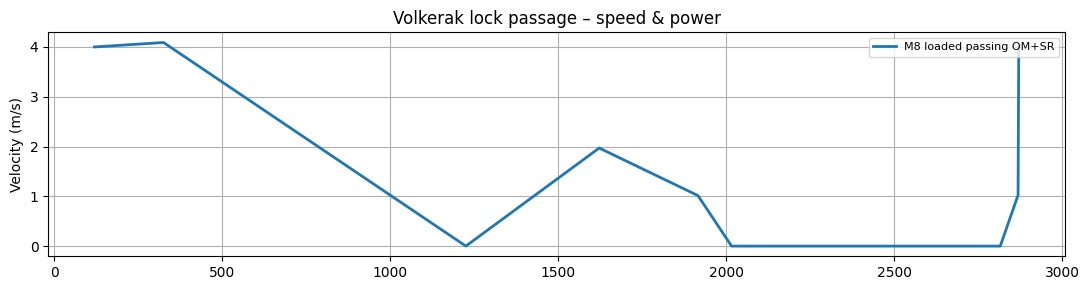

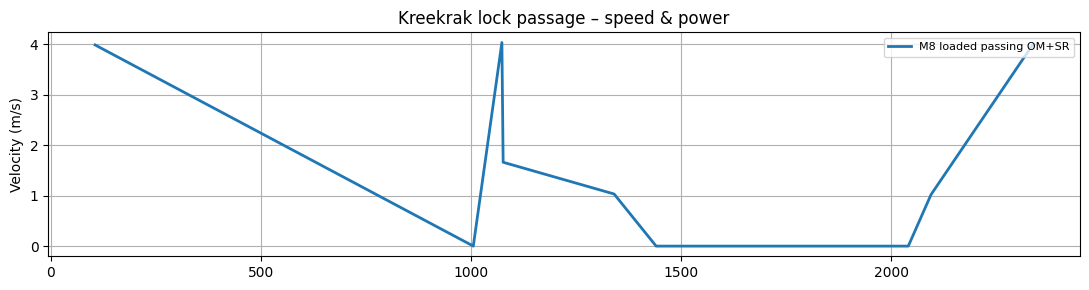

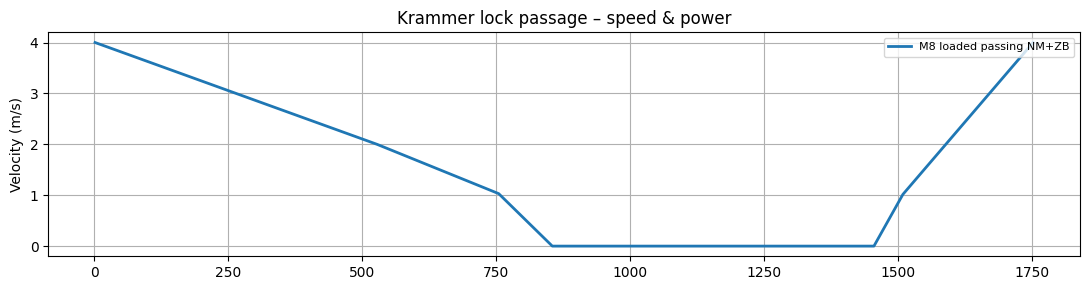

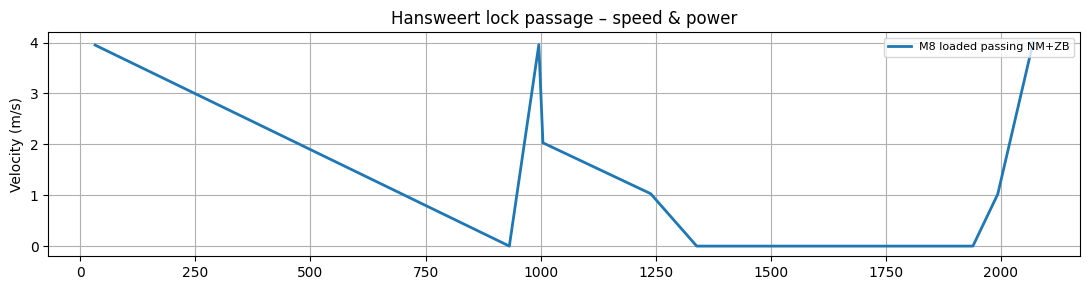

In [38]:
df = df_eventtable_energy_H2.copy()
df = df.sort_values("start time")

# Keep only LOADED vessels on relevant routes
df = df[
    df["object name"].str.contains(" loaded", na=False) &
    (
        df["object name"].str.contains("NM\\+ZB", na=False) |
        df["object name"].str.contains("OM\\+SR", na=False)
    )
]

locks = {
    "Volkerak": {
        "A": information_Volkerak["lock_node_A"],
        "B": information_Volkerak["lock_node_B"],
    },
    "Kreekrak": {
        "A": information_Kreekrak["lock_node_A"],
        "B": information_Kreekrak["lock_node_B"],
    },
    "Krammer": {
        "A": information_Krammer["lock_node_A"],
        "B": information_Krammer["lock_node_B"],
    },
    "Hansweert": {
        "A": information_Hansweert["lock_node_A"],
        "B": information_Hansweert["lock_node_B"],
    },
}

base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for lock_name, nodes in locks.items():

    nodeA = nodes["A"]
    nodeB = nodes["B"]

    # rows belonging to this lock
    mask_lock = (
        df["main activity name"].str.contains(nodeA, na=False) |
        df["main activity name"].str.contains(nodeB, na=False) |
        df["start location"].astype(str).str.contains(nodeA, na=False) |
        df["stop location"].astype(str).str.contains(nodeB, na=False)
    )

    df_lock = df[mask_lock].copy()

    # Only 1 plot for volkerak
    if lock_name == "Volkerak":
        df_lock = df_lock[
            df_lock["object name"].str.contains("OM\\+SR", na=False)
        ]

        # pick exactly one vessel
        one_object_id = df_lock["object id"].iloc[0]
        df_lock = df_lock[df_lock["object id"] == one_object_id]


    # Plots
    # fig, (ax_v, ax_p) = plt.subplots(
    fig, (ax_v) = plt.subplots(
        # 2, 1, figsize=(11, 7), sharex=True
        1, 1, figsize=(11, 3), sharex=True
    )

    for i, (route, g) in enumerate(df_lock.groupby("object name")):

        g = g.sort_values("start time").copy()
        g["distance_cum_km"] = g["distance (m)"].cumsum() / 1000
        g["time_cum_s"] = g["duration (s)"].cumsum()

        color = base_colors[i % len(base_colors)]

        # Velocity
        ax_v.plot(
            # g["distance_cum_km"],
            g["time_cum_s"],
            g["velocity (m/s)"],
            # drawstyle="steps-post",
            linewidth=2,
            color=color,
            label=route
        )

        # Power
        # ax_p.plot(
        #     g["distance_cum_km"],
        #     g["P_given (kW)"],
        #     drawstyle="steps-post",
        #     linestyle="--",
        #     linewidth=2,
        #     color=color,
        #     label=route
        # )

    ax_v.set_ylabel("Velocity (m/s)")
    ax_v.set_title(f"{lock_name} lock passage – speed & power")
    ax_v.grid(True)
    ax_v.legend(fontsize=8, loc="upper right")

    
    # x_node_a = 0.0
    # x_node_b = g["distance_cum_km"].iloc[-1]
    
    # ax_v.set_xticks([x_node_a, x_node_b])
    # ax_v.set_xticklabels(["Node A", "Node B"])

    # ax_p.set_xlabel("Distance between node A and B (km)")
    # ax_p.set_ylabel("P_given (kW)")
    # ax_p.grid(True)

    plt.tight_layout()
    plt.show()

In [39]:
# Event totals + unit conversion + speed 
# vessels = [vessel_1, vessel_2, vessel_3, vessel_4, vessel_5, vessel_6, vessel_7, vessel_8]
# vessels =[vessel_1, vessel_3, vessel_5, vessel_7]
vessels =[vessel_1, vessel_2, vessel_3, vessel_4]

df_event = (
    df_eventtable
    .groupby('object name')
    .agg({'duration (s)': 'sum', 'distance (m)': 'sum'})
)
df_event['duration (h)']      = df_event['duration (s)'] / 3600
df_event['distance (km)']     = df_event['distance (m)'] / 1000
df_event['avg speed (m/s)']   = df_event['distance (m)'] / df_event['duration (s)']
# df_event['avg_speed_km_h']    = df_event['avg_speed_m_s'] * 3.6

df_shallow = (
    df_eventtable
    .loc[df_eventtable["waterdepth (m)"] < 6]
    .groupby("object name", as_index=True)["distance (m)"].sum()
    .rename("shallow_distance_m")
    .to_frame()
)
df_shallow["shallow distance (km)"] = df_shallow["shallow_distance_m"] / 1000

df_partial_load = (
    df_eventtable_energy
    .groupby('object name')
    .agg({'P_given (kW)': 'sum', 'P_installed (kW)': 'sum'})
)
df_partial_load['P_partial'] = df_partial_load['P_given (kW)'] / df_partial_load['P_installed (kW)']
	
# Diesel energy & fuel
df_fuel = (
    df_eventtable_energy_H2
    .groupby('object name')
    # .agg({'total_energy (kWh)': 'sum', 'diesel_consumption (g)': 'sum'})
    .agg({'total_energy (kWh)': 'sum'})
)
# df_fuel['diesel_consumption (kg)'] = df_fuel['diesel_consumption (g)'] / 1000
 
# H2 energy & fuel
df_H2 = (
    df_eventtable_energy_H2
    .groupby('object name')
    .agg({'total_energy (kWh)': 'sum', 'H2_consumption (g)': 'sum'})
)
df_H2['H2_consumption (kg)'] = df_H2['H2_consumption (g)'] / 1000

# Final summary table 
summary = (
    df_event[['duration (h)', 'distance (km)', 'avg speed (m/s)']]    
    .join(df_shallow[["shallow distance (km)"]])
    .join(df_partial_load[['P_partial']])  
    # .join(df_fuel[['total_energy (kWh)', 'diesel_consumption (kg)']])
    .join(df_fuel[['total_energy (kWh)']])
    .join(df_H2[['H2_consumption (kg)']])
    .round(2)
    .reindex([v.name for v in vessels])
)

summary = summary.assign(
    # energy_per_km = summary['total_energy (kWh)'] / summary['distance (km)'],
    # energy_per_h  = summary['total_energy (kWh)'] / summary['duration (h)'],
    H2_per_km     = summary['H2_consumption (kg)'] / summary['distance (km)'],
    H2_per_h      = summary['H2_consumption (kg)'] / summary['duration (h)']
).round(2)

summary


,duration (h),distance (km),avg speed (m/s),shallow distance (km),P_partial,total_energy (kWh),H2_consumption (kg),H2_per_km,H2_per_h
object name,,,,,,,,,
M8 loaded passing OM+SR,8.27,102.70,3.45,22.41,0.32,4737.95,326.67,3.18,39.50
M8 loaded passing NM+SR,8.96,112.72,3.49,34.21,0.34,5288.60,364.63,3.23,40.70
M8 loaded passing OM+ZB,10.94,132.95,3.38,NaN,0.29,5786.95,398.99,3.00,36.47
M8 loaded passing NM+ZB,11.64,142.97,3.41,11.80,0.32,6337.59,436.96,3.06,37.54


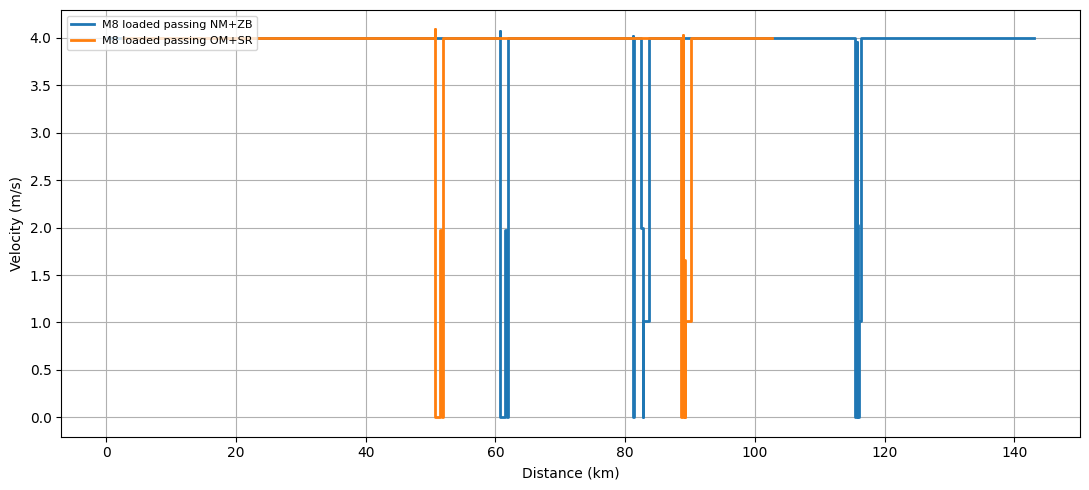

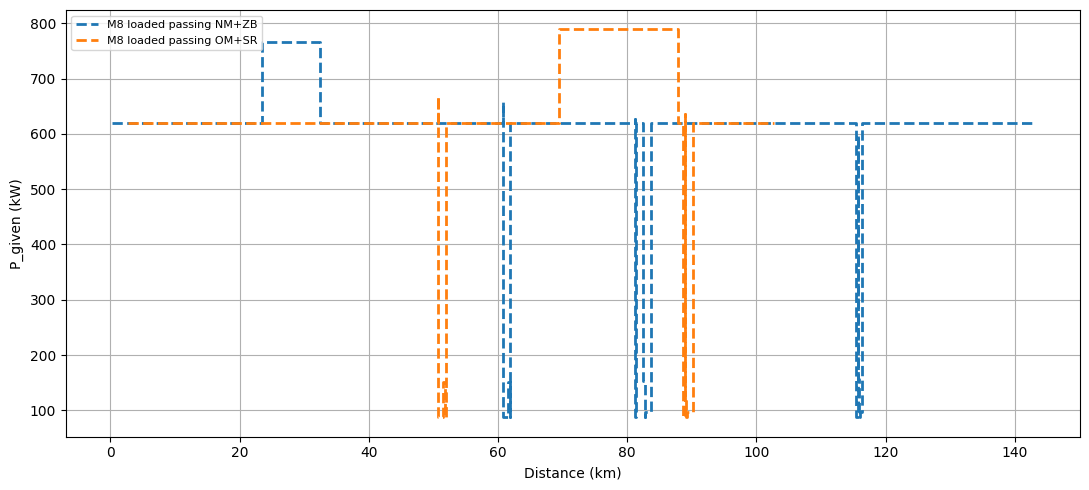

In [40]:
df = df_eventtable_energy_H2.copy()
df = df.sort_values("start time")

#Keep only LOADED vessels
# df = df[df["object name"].str.contains(" loaded")]

# Keep only LOADED and 2 revelant ROUTES
df = df[
    df["object name"].str.contains(" loaded", na=False) &
    (
        df["object name"].str.contains("NM\\+ZB", na=False) |
        df["object name"].str.contains("OM\\+SR", na=False)
    )
]

# Prepare figure
fig, ax = plt.subplots(figsize=(11, 5))

base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Group per route
for i, (route, g) in enumerate(df.groupby("object name")):

    g = g.copy()
    g["distance_cum_km"] = g["distance (m)"].cumsum() / 1000

    color = base_colors[i % len(base_colors)]

    ax.plot(
        g["distance_cum_km"],
        g["velocity (m/s)"],
        drawstyle="steps-post",
        linewidth=2,
        color=color,
        label=route
    )

ax.set_xlabel("Distance (km)")
ax.set_ylabel("Velocity (m/s)")
ax.grid(True)
ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

# Copy & sort
df = df_eventtable_energy_H2.copy()
df = df.sort_values("start time")

# Keep only LOADED vessels
# df = df[df["object name"].str.contains(" loaded")]

# Keep only LOADED and 2 revelant ROUTES
df = df[
    df["object name"].str.contains(" loaded", na=False) &
    (
        df["object name"].str.contains("NM\\+ZB", na=False) |
        df["object name"].str.contains("OM\\+SR", na=False)
    )
]

# Prepare figure
fig, ax = plt.subplots(figsize=(11, 5))

base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Group per route
for i, (route, g) in enumerate(df.groupby("object name")):

    g = g.copy()
    g["distance_cum_km"] = g["distance (m)"].cumsum() / 1000

    color = base_colors[i % len(base_colors)]

    ax.plot(
        g["distance_cum_km"],
        g["P_given (kW)"],
        drawstyle="steps-post",
        linestyle="--",
        linewidth=2,
        color=color,
        label=route
    )

ax.set_xlabel("Distance (km)")
ax.set_ylabel("P_given (kW)")
ax.grid(True)
ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()


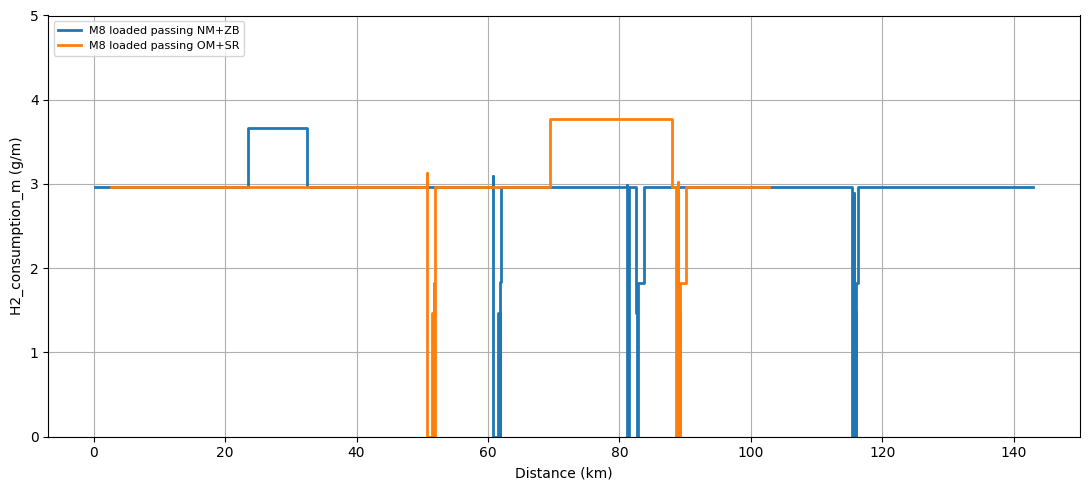

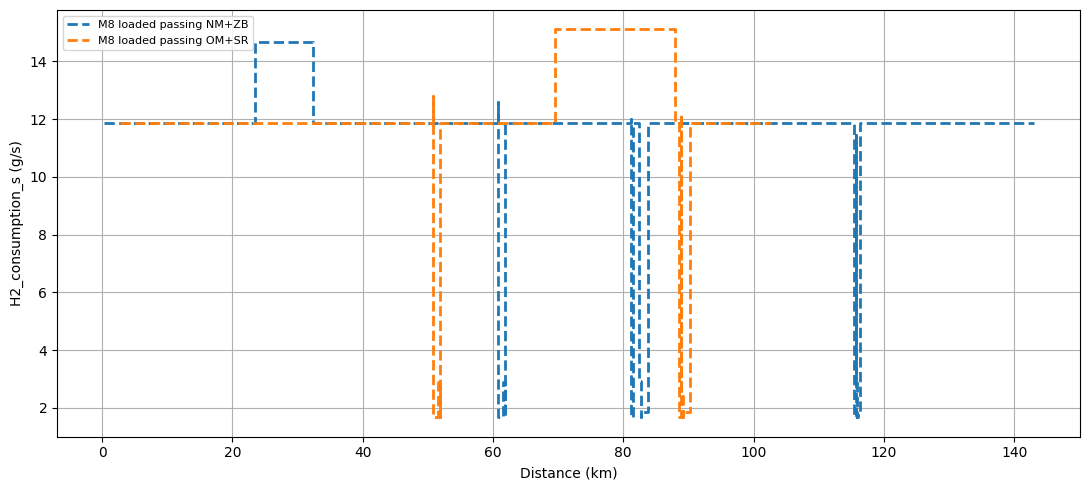

In [41]:
df = df_eventtable_energy_H2.copy()
df = df.sort_values("start time")

#Keep only LOADED vessels
# df = df[df["object name"].str.contains(" loaded")]

# Keep only LOADED and 2 revelant ROUTES
df = df[
    df["object name"].str.contains(" loaded", na=False) &
    (
        df["object name"].str.contains("NM\\+ZB", na=False) |
        df["object name"].str.contains("OM\\+SR", na=False)
    )
]


# Prepare figure
fig, ax = plt.subplots(figsize=(11, 5))

base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Group per route
for i, (route, g) in enumerate(df.groupby("object name")):

    g = g.copy()
    g["distance_cum_km"] = g["distance (m)"].cumsum() / 1000

    color = base_colors[i % len(base_colors)]

    ax.plot(
        g["distance_cum_km"],
        g["H2_consumption_m (g/m)"],
        drawstyle="steps-post",
        # linestyle="--",
        linewidth=2,
        color=color,
        label=route
    )

ax.set_xlabel("Distance (km)")
ax.set_ylabel("H2_consumption_m (g/m)")
ax.set_ylim(0,5)
ax.grid(True)
ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

# Copy & sort
df = df_eventtable_energy_H2.copy()
df = df.sort_values("start time")

# Keep only LOADED vessels
# df = df[df["object name"].str.contains(" loaded")]

# Keep only LOADED and 2 revelant ROUTES
df = df[
    df["object name"].str.contains(" loaded", na=False) &
    (
        df["object name"].str.contains("NM\\+ZB", na=False) |
        df["object name"].str.contains("OM\\+SR", na=False)
    )
]

# Prepare figure
fig, ax = plt.subplots(figsize=(11, 5))

base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Group per route
for i, (route, g) in enumerate(df.groupby("object name")):

    g = g.copy()
    g["distance_cum_km"] = g["distance (m)"].cumsum() / 1000

    color = base_colors[i % len(base_colors)]

    ax.plot(
        g["distance_cum_km"],
        g["H2_consumption_s (g/s)"],
        drawstyle="steps-post",
        linestyle="--",
        linewidth=2,
        color=color,
        label=route
    )

ax.set_xlabel("Distance (km)")
ax.set_ylabel("H2_consumption_s (g/s)")
ax.grid(True)
ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()


#### Trying to print speed and power over distance for the four locks

#### Multipyling with fleet

In [42]:
# Insert count of vessels per route section 
Nieuwe_Maas   = 232
Oude_Maas     = 203
Zuid_Beveland = 182
Scheldt_Rhine = 271

# Compute ratios 
Ratio_NM   = Nieuwe_Maas/(Nieuwe_Maas + Oude_Maas)
Ratio_OM   = Oude_Maas/(Nieuwe_Maas + Oude_Maas)
Ratio_ZB   = Zuid_Beveland/(Zuid_Beveland + Scheldt_Rhine)
Ratio_SR   = Scheldt_Rhine/(Zuid_Beveland + Scheldt_Rhine)

# Insert loading ratio
Ratio_loaded = 0.5
Ratio_empty  = 1 - Ratio_loaded 

In [43]:
# Insert total vessels 
total_vessels = 250

OM_SR_loaded  = total_vessels * Ratio_OM * Ratio_SR * Ratio_loaded
OM_SR_empty   = total_vessels * Ratio_OM * Ratio_SR * Ratio_empty
NM_SR_loaded  = total_vessels * Ratio_NM * Ratio_SR * Ratio_loaded
NM_SR_empty   = total_vessels * Ratio_NM * Ratio_SR * Ratio_empty
OM_ZB_loaded  = total_vessels * Ratio_OM * Ratio_ZB * Ratio_loaded
OM_ZB_empty   = total_vessels * Ratio_OM * Ratio_ZB * Ratio_empty
NM_ZB_loaded  = total_vessels * Ratio_NM * Ratio_ZB * Ratio_loaded
NM_ZB_empty   = total_vessels * Ratio_NM * Ratio_ZB * Ratio_empty

print("Computed route ratios ---")
print(f"NM ratio (Nieuwe / Total Maas) : {Ratio_NM:.3f} ({Ratio_NM:.1%})")
print(f"OM ratio (Oude / Total Maas)   : {Ratio_OM:.3f} ({Ratio_OM:.1%})")
print(f"ZB ratio (Zuid Beveland)       : {Ratio_ZB:.3f} ({Ratio_ZB:.1%})")
print(f"SR ratio (Scheldt–Rhine)       : {Ratio_SR:.3f} ({Ratio_SR:.1%})")

Computed route ratios ---
NM ratio (Nieuwe / Total Maas) : 0.533 (53.3%)
OM ratio (Oude / Total Maas)   : 0.467 (46.7%)
ZB ratio (Zuid Beveland)       : 0.402 (40.2%)
SR ratio (Scheldt–Rhine)       : 0.598 (59.8%)


#### Fleet totals

In [44]:
# Fleet definition
fleet_map = {
    "M8 loaded passing OM+SR": OM_SR_loaded,
    # "M8 unloaded passing OM+SR": OM_SR_empty,
    "M8 loaded passing NM+SR": NM_SR_loaded,
    # "M8 unloaded passing NM+SR": NM_SR_empty,
    "M8 loaded passing OM+ZB": OM_ZB_loaded,
    # "M8 unloaded passing OM+ZB": OM_ZB_empty,
    "M8 loaded passing NM+ZB": NM_ZB_loaded,
    # "M8 unloaded passing NM+ZB": NM_ZB_empty,
}

# Build fleet totals table (per vessel values)
summary_fleet_totals = (
    summary
    .loc[:, ['total_energy (kWh)', 'H2_consumption (kg)']]
    .rename(columns={
        'total_energy (kWh)': 'total_energy_vessel (kWh)',
        'H2_consumption (kg)': 'H2_consumption_vessel (kg)'
    })
)

# Add & round number of vessels BEFORE scaling
summary_fleet_totals.insert(
    0,
    'number of vessels',
    summary_fleet_totals.index.map(fleet_map).round(0).astype(int)
)

# Fleet totals
summary_fleet_totals['total_energy_fleet (kWh)'] = (
    summary_fleet_totals['total_energy_vessel (kWh)']
    * summary_fleet_totals['number of vessels']
)

summary_fleet_totals['H2_consumption_fleet (kg)'] = (
    summary_fleet_totals['H2_consumption_vessel (kg)']
    * summary_fleet_totals['number of vessels']
)

# Add TOTAL FLEET row
total_row = (
    summary_fleet_totals
    .sum()
    .to_frame()
    .T
)
total_row.index = ['TOTAL FLEET']

summary_fleet_totals = pd.concat(
    [summary_fleet_totals, total_row]
).round(2)

summary_fleet_totals

,number of vessels,total_energy_vessel (kWh),H2_consumption_vessel (kg),total_energy_fleet (kWh),H2_consumption_fleet (kg)
M8 loaded passing OM+SR,35.0,4737.95,326.67,165828.25,11433.45
M8 loaded passing NM+SR,40.0,5288.60,364.63,211544.00,14585.20
M8 loaded passing OM+ZB,23.0,5786.95,398.99,133099.85,9176.77
M8 loaded passing NM+ZB,27.0,6337.59,436.96,171114.93,11797.92
TOTAL FLEET,125.0,22151.09,1527.25,681587.03,46993.34
